##  Изучение рынка заведений общественного питания Москвы
### Цель и задачи  

**Цель:** Провести исследовательский анализ данных рынка заведений общественного питания Москвы.   

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально.
4. Сформулировать выводы по проведённому анализу.


### Данные

Для анализа поступили данные о заведениях общественного питания Москвы. Данные состоят из двух датасетов:

- `rest_info.csv` — информация о заведениях общественного питания;
- `rest_price.csv` —  информация о среднем чеке в заведениях общественного питания.

### Описание датасета `rest_info`

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение;
- `category` — категория заведения;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым;
- `seats` — количество посадочных мест.

### Описание датасета `rest_price`

- `price` — категория цен в заведении;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»;
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино».

### Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---


### 1. Загрузка данных и знакомство с ними
#### 1.1. Первчиный просмотр данных
Начнём с загрузки библиотек и датасетов `rest_info` и `rest_price`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `info_df` и `price_df`.

In [1]:
!pip install phik

In [2]:
# Импортируем библиотеки
import pandas as pd
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix


In [3]:
import pandas as pd
import os

# Пытаемся загрузить с локального пути, если нет - с серверного
try:
    info_df = pd.read_csv('C:/Users/mobil/Desktop/курсики/спринт 8/rest_info.csv') 
    price_df = pd.read_csv('C:/Users/mobil/Desktop/курсики/спринт 8/rest_price.csv')
    print("Локальная загрузка")
except FileNotFoundError:
    info_df = pd.read_csv('/datasets/rest_info.csv')
    price_df = pd.read_csv('/datasets/rest_price.csv')
    print("Серверная загрузка")

Локальная загрузка


Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [4]:
info_df[:5]

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 8406 строк и 9 столбцов. Пропуски содержатся только в двух столбцах – `hours` и `seats`. Названия столбцов представлены в правильном виде. 6 столбцов имеют тип данных object, 2 – вещественный тип и 1 столбец целочисленного типа. Столбец `chain` показывает наличие у клиента того или иного признака и содержит значения 1 или 0 — размерность этих данных можно оптимизировать. Судя по всему, данные столбцов соответствуют своему описанию.

In [6]:
price_df[:5]

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` содержит 4058 строк и 5 столбцов. Здесь изначально больше чем в 2 раза меньше заведений, чем в датасете `rest_info.csv`. Только `id` не содержит пропусков. Это может значить, что некоторые заведения еще не принимали заказов, поэтому имеют пустой столбец `avg_bill`, что приводит к непременному не заполнению `middle_avg_bill` и `middle_coffee_cup`, так как они вычисляются за счет него. Все названия столбцов указаны в snake_case. В датасете представлены 3 столбца типа object, 2 столбца вещественного типа. 

---

#### 1.2. Объединение датафреймов

In [8]:
# Проверяем дубликаты в info_df
print("Дубликаты в info_df:", info_df['id'].duplicated().sum())
print("Уникальных id:", info_df['id'].nunique())

# Проверяем дубликаты в price_df
print("Дубликаты в price_df:", price_df['id'].duplicated().sum())
print("Уникальных id:", price_df['id'].nunique())

Дубликаты в info_df: 0
Уникальных id: 8406
Дубликаты в price_df: 0
Уникальных id: 4058


In [9]:
#Объединим данные двух датасетов в один, с которым мы и продолжим работу.
df = info_df.merge(price_df, on='id', how = 'left')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


In [11]:
df.describe()

,rating,chain,seats,middle_avg_bill,middle_coffee_cup
count,8406.000000,8406.000000,4795.000000,3149.000000,535.000000
mean,4.229895,0.381275,108.421689,958.053668,174.721495
std,0.470348,0.485729,122.833396,1009.732845,88.951103
min,1.000000,0.000000,0.000000,0.000000,60.000000
25%,4.100000,0.000000,40.000000,375.000000,124.500000
50%,4.300000,0.000000,75.000000,750.000000,169.000000
75%,4.400000,1.000000,140.000000,1250.000000,225.000000
max,5.000000,1.000000,1288.000000,35000.000000,1568.000000


In [12]:
df.nunique()

id                   8406
name                 5614
category                8
address              5753
district                9
hours                1307
rating                 41
chain                   2
seats                 229
price                   4
avg_bill              897
middle_avg_bill       230
middle_coffee_cup      96
dtype: int64

Данные соединены, и информация обо всех заведениях сохранилась. Были изучены основные показатели датафрейма и количество уникальных значений по столбцам.

---

### 2. Предобработка данных

#### 2.1. Оптимизируем типы данных

In [13]:
# Оптимизируем целочисленный тип данных
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [14]:
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                   int8
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

Типы данных были успешно оптимизированы с понижением размерности целочисленных данных.

---

#### 2.2. Проверяем наличие пропусков в данных

Узнаем абсолютное и относительное количество пропусков в столбцах с пропусками.

In [15]:
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [16]:
df.isna().sum() / df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

В датафрейме `df` обнаружено большое количество пропусков в столбцах `seats`, `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`, доля достигает от 42 до 93% данных. Количество пропусков достаточно большое, чтобы их удалить, поэтому оставляем в исходном состоянии.

Чтобы определить, что заведение работает ежедневно и круглосуточно, то есть 24/7 напишем небольшую функцию:


In [18]:
result = df[df.index == 699][['hours', 'is_24_7']]
print(result.to_string())

                                                                                           hours  is_24_7
699  пн 00:01–12:00, перерыв 12:00–13:30; вт-чт 13:30–12:00; пт 13:30–00:00; сб,вс круглосуточно     True


---

#### 2.3. Явные и неявные дубликаты в данных

Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [19]:
df.duplicated().sum()

np.int64(0)

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты — значения по `id` заведений должны быть уникальными, то есть каждая строка в данных — уникальный клиент:

In [20]:
df.duplicated(subset='id').sum()

np.int64(0)

In [21]:
cols_to_check = ['name', 'category', 'address', 'district']

for col in cols_to_check:
    df[col] = df[col].astype(str).str.lower()

# Находим дубликаты по этим колонкам
duplicates = df[df.duplicated(subset=cols_to_check, keep=False)]
print(f"Найдено неполных дубликатов: {len(duplicates)} строк")
print("Дубликаты:")
print(duplicates[cols_to_check])

Найдено неполных дубликатов: 4 строк
Дубликаты:
           name  category                                  address  \
189        кафе      кафе             москва, парк ангарские пруды   
215        кафе      кафе             москва, парк ангарские пруды   
1430  more poke  ресторан  москва, волоколамское шоссе, 11, стр. 2   
1511  more poke  ресторан  москва, волоколамское шоссе, 11, стр. 2   

                             district  
189   северный административный округ  
215   северный административный округ  
1430  северный административный округ  
1511  северный административный округ  


In [22]:
df = df.drop_duplicates(subset=cols_to_check, keep='first')

Удалили неплоные дубликаты, применив все строки к нижнему регистру. 2 строки дубликатов удалены. Теперь проверим корректность написания значений в данных.

In [23]:
for column in ['category', 'district', 'chain', 'rating', 'price']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце district:
['восточный административный округ' 'западный административный округ'
 'северный административный округ'
 'северо-восточный административный округ'
 'северо-западный административный округ'
 'центральный административный округ'
 'юго-восточный административный округ'
 'юго-западный административный округ' 'южный административный округ']

Уникальные значения в столбце chain:
[0 1]

Уникальные значения в столбце rating:
[1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7
 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3 4.4 4.5
 4.6 4.7 4.8 4.9 5. ]

Уникальные значения в столбце price:
['высокие' 'выше среднего' 'низкие' 'средние' nan]



Все значения выглядят корректными. 

---

In [24]:
# check
df[df['address'].fillna('').str.split().str.len() < 4]['address']

25                 москва, парк левобережный
73                    москва, парк алтуфьево
484                      москва, парк дружбы
541              москва, ленинградское шоссе
790                 москва, грузинский сквер
874                   москва, парк останкино
1007                  москва, парк останкино
1848             москва, улица черняховского
2350                  москва, рижский проезд
2365                 москва, парк сокольники
2405                 москва, парк сокольники
2430                  москва, песочная аллея
2532              москва, улица гиляровского
3310              москва, ворошиловский парк
3833                     москва, сад эрмитаж
3963           москва, пушкинская набережная
4911       москва, коммунистический переулок
5191              москва, павелецкая площадь
5404                     москва, парк радуга
5445              москва, терлецкий лесопарк
5479              москва, авиамоторная улица
5582                     москва, парк радуга
5958      

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8404 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8404 non-null   object 
 1   name               8404 non-null   object 
 2   category           8404 non-null   object 
 3   address            8404 non-null   object 
 4   district           8404 non-null   object 
 5   hours              7868 non-null   object 
 6   rating             8404 non-null   float64
 7   chain              8404 non-null   int8   
 8   seats              4794 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
 13  is_24_7            8404 non-null   bool   
dtypes: bool(1), float64(4), int8(1), object(8)
memory usage: 869.9+ KB


#### 2.4. Промежуточные выводы после предобработки

В результате предобработки данных были выполнены следующие действия:

- Изучены пропуски в данных. Пропуски обнаружились в столбцах `seats`, `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`, пропуски составили от 42 до 93% данных. Они могут отражать не указанную информацию заведением или свидетельствовать о его недавнем открытии и не являться ошибкой в данных. Поэтому их оставили как есть.
- Данные проверили на явные и неявные дубликаты — в данных было 4 неполных дубликата, дубликаты были удалены.

В исследовательском разделе будет использовано 8404 строк датафрейма, который был объединен из двух исходных. Количество стобцов: 14. Их предобработка была завершена и данные готовы к анализу. 

---

### 3. Исследовательский анализ данных

Для начала посмотрим сколько значений в себе содержит каждая категория, чтобы понимать, какие более популярны и востребованы.

In [26]:
df['category'].value_counts()

category
кафе               2377
ресторан           2042
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: count, dtype: int64

In [27]:
df['category'].value_counts(normalize=True) * 100

category
кафе               28.284150
ресторан           24.297953
кофейня            16.813422
бар,паб             9.102808
пиццерия            7.532128
быстрое питание     7.175155
столовая            3.748215
булочная            3.046168
Name: proportion, dtype: float64

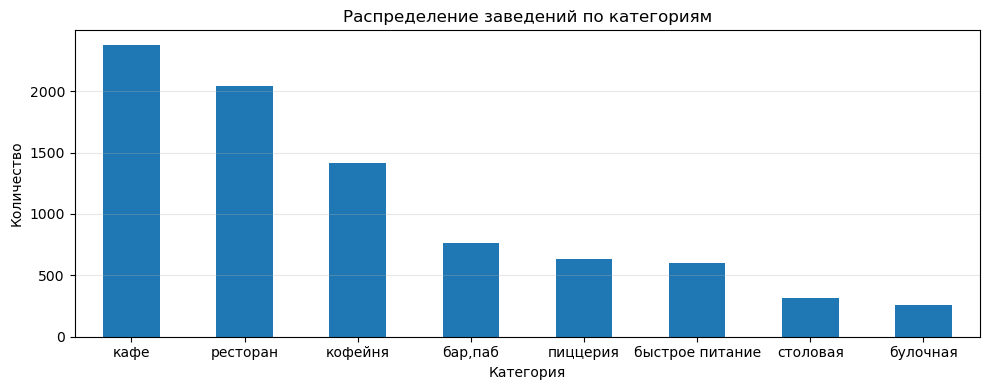

In [28]:
#Сделаем визуализацию по распределению заведений по категориям в виде столбчатой диаграммы
df['category'].value_counts().plot(kind = 'bar',
        title = 'Распределение заведений по категориям',
        legend = False,
        ylabel = 'Количество',
        xlabel = 'Категория',
        rot = 0,
        figsize = (10, 4))
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

В итоге, кафе является самой популярной категорией (28% - 2377), ресторан (24% - 2042) и кофейня (около 17% - 1413) немногим менее популярны. Самые непопулярные категории – столовая и булочная. Далее посмотрим, как поменяются значения, если исключить сетевые значения и оценить количество уникальных заведений.

In [29]:
#Выделим уникальные названия заведений, чтобы исключить сетевые
unique_categories = df[df['chain'] == 0].groupby('category')['name'].nunique().sort_values(ascending=False)
print(unique_categories)

category
кафе               1399
ресторан           1273
кофейня             675
бар,паб             592
быстрое питание     328
пиццерия            298
столовая            190
булочная             97
Name: name, dtype: int64


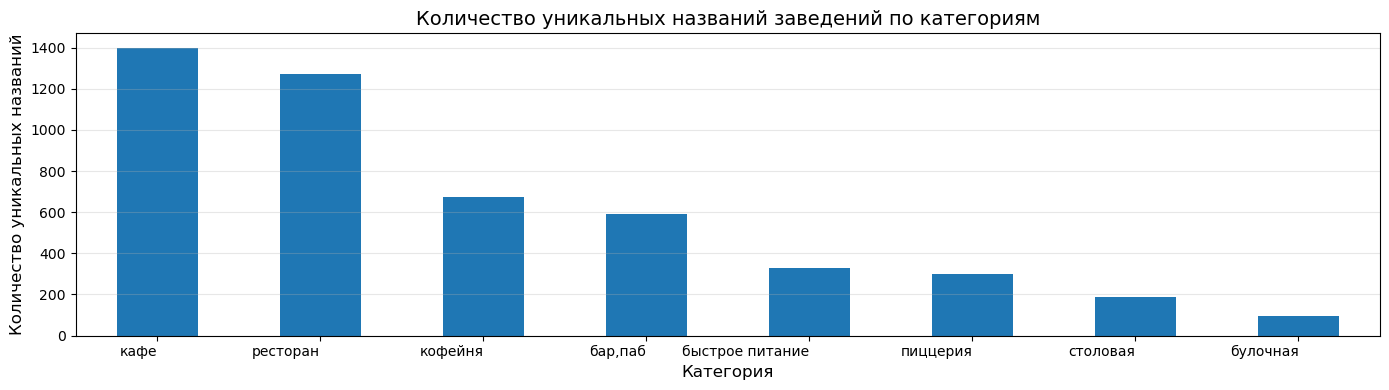

In [30]:
plt.figure(figsize=(14, 4))
unique_categories.plot(kind='bar')
plt.title('Количество уникальных названий заведений по категориям', fontsize=14)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Количество уникальных названий', fontsize=12)
plt.xticks(rotation=0, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

По изображению видно, что соотношение заведений осталось примерно тем же, что означает не сильное влияние сетевых заведений на распределение заведений по категориям в общем. Однако из всех категорий стоит отметить кофейни, их значение уменьшилось больше всех, что означает самую сильную приверженность из всех категорий к сетевой модели.

Далее рассмотрим распределение заведений по районам Москвы. Это поможет понять, где размещено больше всего заведений.

In [31]:
district_short = {
    'центральный административный округ': 'ЦАО',
    'северный административный округ': 'САО',
    'северо-восточный административный округ': 'СВАО',
    'восточный административный округ': 'ВАО',
    'юго-восточный административный округ': 'ЮВАО',
    'южный административный округ': 'ЮАО',
    'юго-западный административный округ': 'ЮЗАО',
    'западный административный округ': 'ЗАО',
    'северо-западный административный округ': 'СЗАО',
    'зеленоградский административный округ': 'ЗелАО',
    'новомосковский административный округ': 'НАО',
    'троицкий административный округ': 'ТАО'
}

df['district_short'] = df['district'].replace(district_short)
# Проверяем
print(df[['district', 'district_short']].drop_duplicates())

                                     district district_short
0             северный административный округ            САО
43    северо-восточный административный округ           СВАО
295    северо-западный административный округ           СЗАО
1185          западный административный округ            ЗАО
1663       центральный административный округ            ЦАО
2108         восточный административный округ            ВАО
4475     юго-восточный административный округ           ЮВАО
4939             южный административный округ            ЮАО
5680      юго-западный административный округ           ЮЗАО


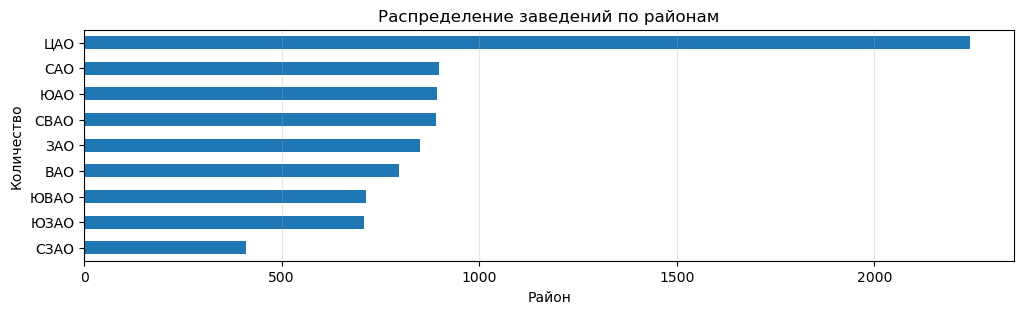

In [32]:
df['district_short'].value_counts().sort_values(ascending=True).plot(kind = 'barh',
        title = 'Распределение заведений по районам',
        legend = False,
        ylabel = 'Количество',
        xlabel = 'Район',
        rot = 0,
        figsize = (12, 3))
plt.grid(axis='x', alpha=0.3)
plt.show()

In [33]:
df['district'].value_counts(normalize=True) * 100

district
центральный административный округ         26.677772
северный административный округ            10.685388
южный административный округ               10.613993
северо-восточный административный округ    10.602094
западный административный округ            10.126130
восточный административный округ            9.495478
юго-восточный административный округ        8.495954
юго-западный административный округ         8.436459
северо-западный административный округ      4.866730
Name: proportion, dtype: float64

Здесь с большим отрывом лидирует ЦАО (Центральный административный округ). Там расположено более чем в два раза больше заведений, чем в других округах по отдельности, это может свидетельствовать о популярности округа, привлекательности для покупателей и удобном расположении.   
Ниже рассмотрим какие именно заведения преобладают в ЦАО.

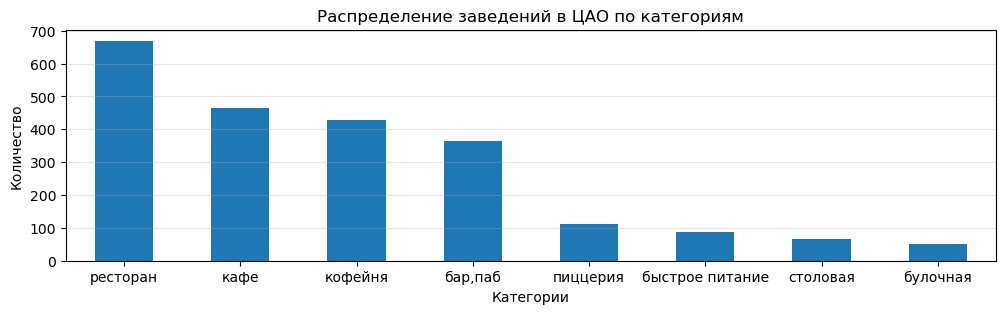

In [34]:
cao_df = df[df['district'] == 'центральный административный округ']
cao_df['category'].value_counts().plot(kind = 'bar',
                                       title = 'Распределение заведений в ЦАО по категориям',
                                       ylabel = 'Количество',
                                       xlabel = 'Категории',
                                       rot = 0,
                                       figsize = (12, 3))

plt.grid(axis='y', alpha=0.3)
plt.show()

In [35]:
cao_df['category'].value_counts(normalize=True) * 100

category
ресторан           29.884032
кафе               20.695807
кофейня            19.090098
бар,паб            16.235504
пиццерия            5.040143
быстрое питание     3.880464
столовая            2.943800
булочная            2.230152
Name: proportion, dtype: float64

Как можно заметить, по сравнению с общей статистикой, в ЦАО лидируют рестораны, а не кафе, которые расположились на втором месте по популярности. Среди прочих, популярны кофейни и бары, пабы. Такое распределение можно обосновать статусом района, который скорее располагает более дорогими и престижными заведениями в виде ресторанов.

Также важно понять, каково соотношение сетевых и несетевых заведений в принципе. Для этого узнаем их абсолютные и относительные значения.

In [36]:
#Абсолютные значения сетевых и несетвых заведений
df['chain'].value_counts()

chain
0    5200
1    3204
Name: count, dtype: int64

In [37]:
#Относительные значения сетевых и несетевых заведений
df['chain'].value_counts(normalize=True) * 100

chain
0    61.875297
1    38.124703
Name: proportion, dtype: float64

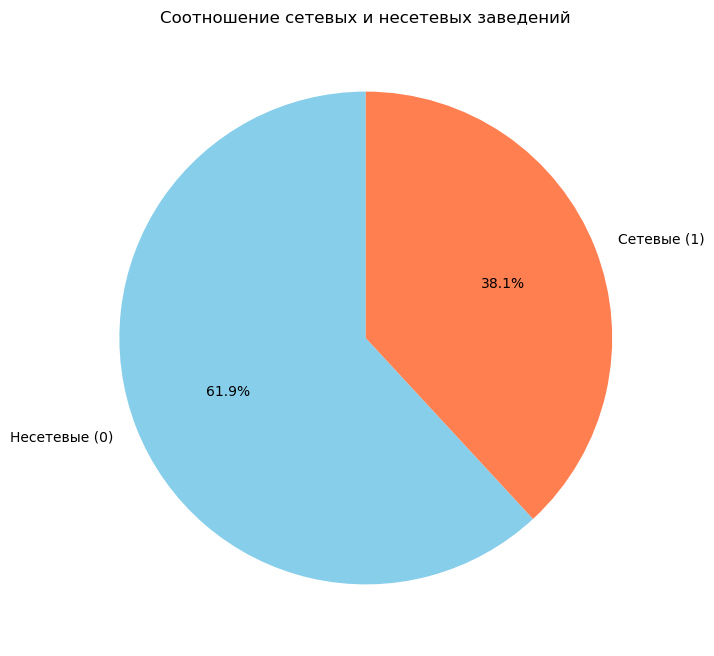

In [38]:
# Круговая диаграмма для соотношения сетевых и несетевых заведений
counts = df['chain'].value_counts()
labels = ['Несетевые (0)', 'Сетевые (1)']

plt.figure(figsize=(8, 8))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'coral'])
plt.title('Соотношение сетевых и несетевых заведений')
plt.show()

Как мы видим, большинство заведений – несетевые (около 62% - 5200). Это говорит о том, что одиночные заведения более популярны в Мосвке. Это может быть связано с тем, что это требует меньше вложений.
Теперь следует узнать, какие именно категории чаще являются сетевыми. Проанализируем распределение сетевых и несетевых заведений в зависимости от категории.

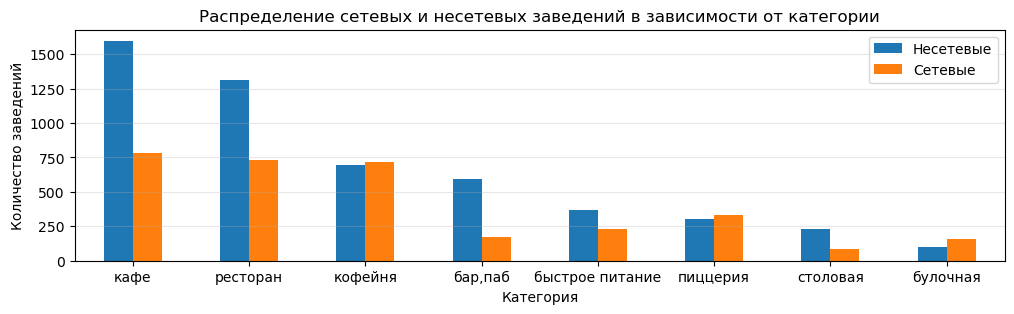

In [39]:
#На столбчатой диаграмме соотнесем количество сетевых и несетвых заведений по категориям 
grouped = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
grouped.columns = ['Несетевые', 'Сетевые']
grouped = grouped.sort_values('Несетевые', ascending=False)
grouped.plot(kind='bar',
               title=f'Распределение сетевых и несетевых заведений в зависимости от категории',
               legend=True,
               ylabel='Количество заведений',
               xlabel='Категория',
               rot=0,
               figsize=(12, 3))
plt.grid(axis='y', alpha=0.3)
plt.show()

На графике видно, что самое большое количество сетевых заведений принадлежит таким категориям, как кафе, ресторан и кофейня. По количеству сетевых заведений относительно всего количества заведений данной категории кофейня имеет даже больше сетевых заведений, что говорит о большой популярности открывать сетевые кофейни в Москве. Рестораны на втором месте по критерию сетевых заведений от общего числа открытых заведений категории.

Также важно различие между долей и абсолютным значением количества точек в сети, потому что существует очень сильный разброс в количестве заведений по категориям.

Следующим шагом необходимо проверить распределение посадочных мест в заведениях. С помощью "ящика с усами" отследим значения и выбросы.

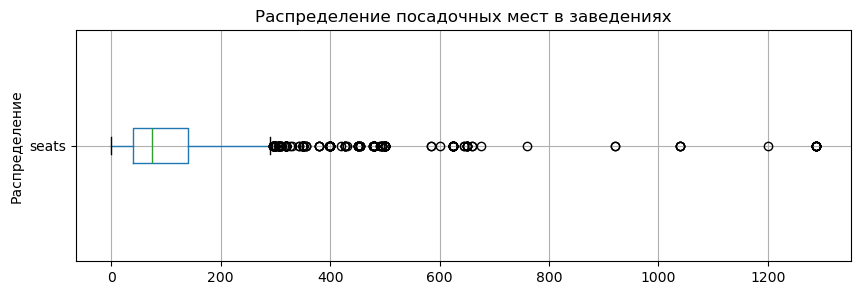

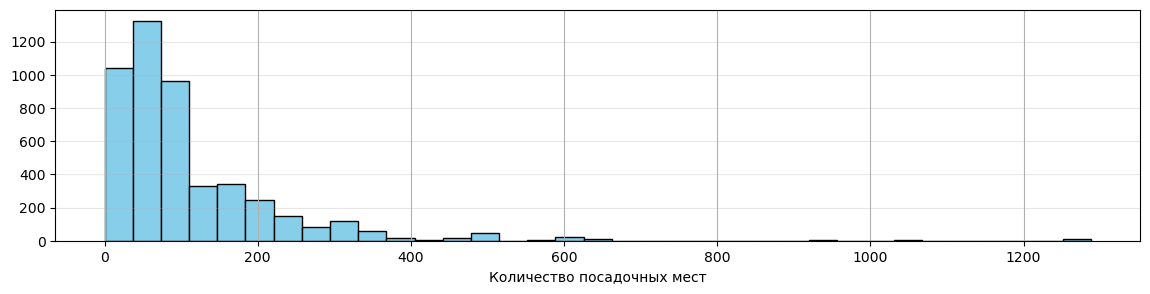

In [40]:
plt.figure(figsize=(10, 3))
df.boxplot(column='seats', vert=False)
plt.title('Распределение посадочных мест в заведениях')
plt.ylabel('Распределение')
plt.show()
plt.figure(figsize=(14, 3))
df['seats'].hist(bins=35, color='skyblue', edgecolor='black')  
plt.xlabel('Количество посадочных мест')
plt.grid(axis='y', alpha=0.3)
plt.show()

Как мы видим, на графике присутствует большое количество выбросов, которые находятся далеко от медины. Распределение устремлено вправо, что говорит о том, что есть заведения с очень большим количеством мест. В данных присутствуют крупные банкетные площадки с вместимостью более 800 мест, что объясняет наличие выбросов на графике.

Проанализируем и визуализируем типичное количество мест (медиану) для каждой категории, чтобы понять какие из них имеют большую наполняемость. 

In [41]:
typical_seats = df.groupby('category')['seats'].median().sort_values(ascending=False)

print("Наиболее типичное количество посадочных мест для каждой категории:")
print(typical_seats)

Наиболее типичное количество посадочных мест для каждой категории:
category
ресторан           86.0
бар,паб            82.5
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64


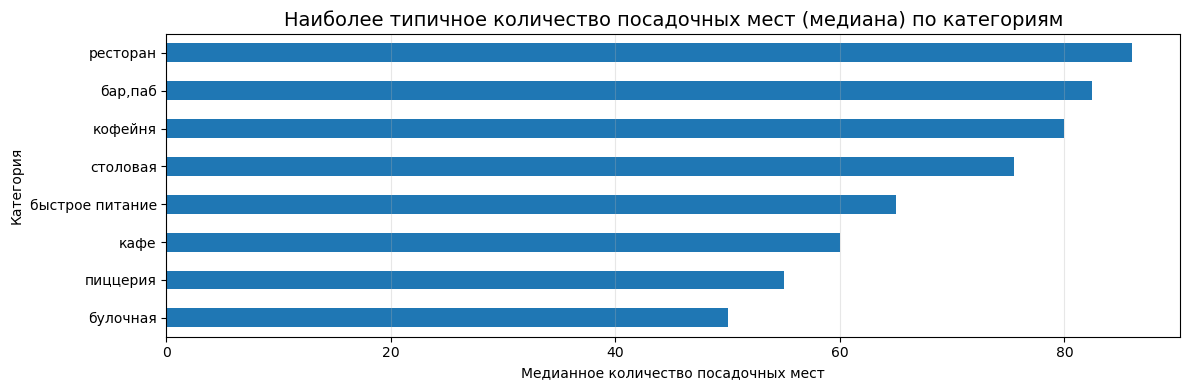

In [42]:
plt.figure(figsize=(12, 4)) 

typical_seats.sort_values().plot(kind='barh')
plt.title('Наиболее типичное количество посадочных мест (медиана) по категориям', fontsize=14)
plt.xlabel('Медианное количество посадочных мест')
plt.ylabel('Категория')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

В результате, ресторан стал самой наполняемой категорией. После него идут бар, паб и кофейня. Самые ненаполняемые категории – пиццерия и булочная. Эти данные могут быть связаны с общим временем пребывания в каждом из заведений и их популярностью. 

Следующим шагом определим и визуализируем средний рейтинг для каждой категории. Это поможет понять, какие заведения обладают большим доверием посетителей.

In [43]:
avg_rating = df.groupby('category')['rating'].mean().sort_values(ascending = False)
print("Средний рейтинг для каждой категории:")
print(avg_rating)

Средний рейтинг для каждой категории:
category
бар,паб            4.387712
пиццерия           4.301264
ресторан           4.290402
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.124274
быстрое питание    4.050249
Name: rating, dtype: float64


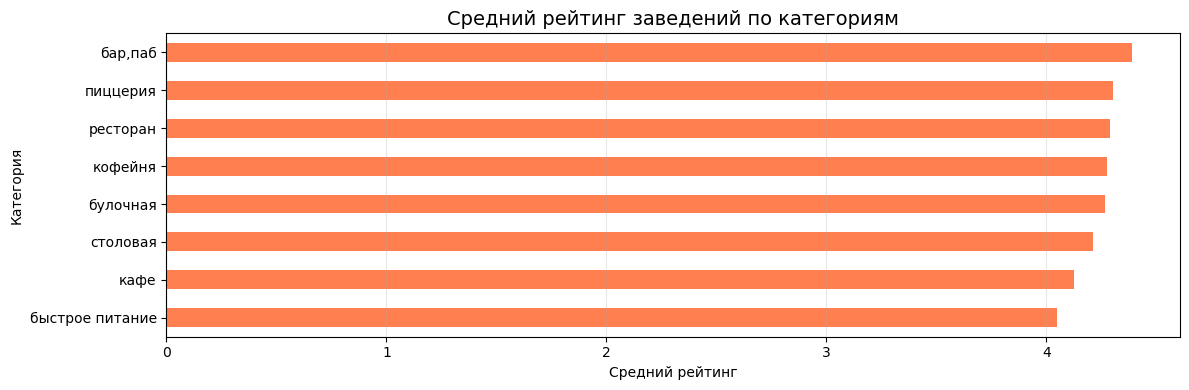

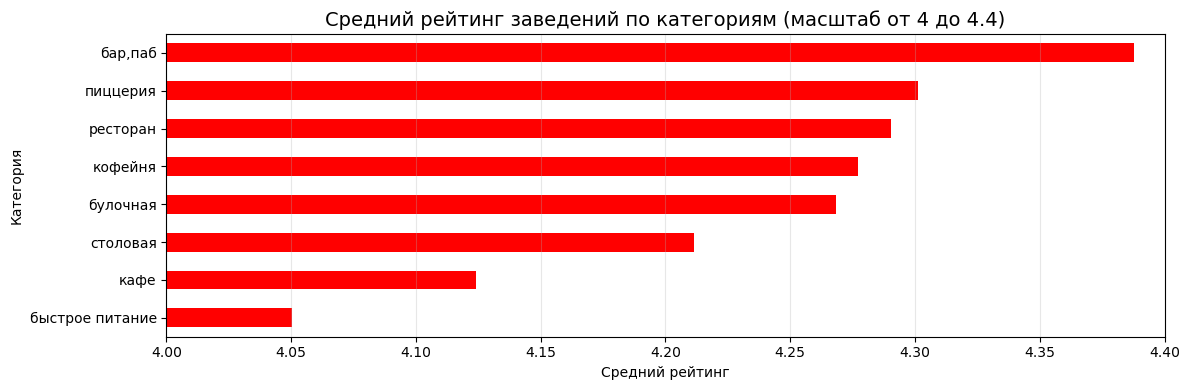

In [44]:
plt.figure(figsize=(12, 4))

avg_rating.sort_values().plot(kind='barh', color = 'coral')
plt.title('Средний рейтинг заведений по категориям', fontsize=14)
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 4))

avg_rating.sort_values().plot(kind='barh', color = 'red')
plt.title('Средний рейтинг заведений по категориям (масштаб от 4 до 4.4)', fontsize=14)
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория')
plt.xlim(4, 4.4)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Как можно увидеть, самый высокий средний рейтинг принадлежит бару, пабу (около 4.39). Чуть ниже рейтинг имеют пиццерия и ресторан. Эти заведения выглядят более привлекательными и надежными в глазах покупателей. Ниже всех располагается быстрое питание (рейтинг чуть более 4). Это может свидетельствовать, наоборот, о недоверии покупателей и не таком высоком качестве заведений и их еды.

Далее посмотрим, как столбцы коррелируют с рейтингом, чтобы узнать, что влияет на рейтинг заведения. Для визуального анализа такого распределения можно использовать тепловую карту.

In [45]:
correlation_matrix = df[['rating', 'category', 'district', 'chain', 'seats',
                         'price', 'is_24_7']].phik_matrix()
# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['rating', 'chain', 'seats']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.220295
district,0.200760
category,0.189779
is_24_7,0.144895
chain,0.107786
seats,0.000000


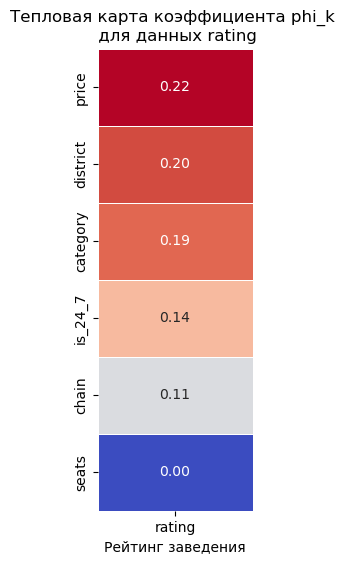

In [46]:
plt.figure(figsize=(2, 6))

data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=False 
           )

plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг заведения')

plt.show()

Рейтинг заведения по результатам слабо коррелирует со столбцами. Мы можем заметить, что больше всего на рейтинг заведения влияет ценовая категория (0.22). Также рядом расположились район (0.2) и категория (0.19). Это может означать, что рейтинг зависит от других признаков, не указанных в данных, например, качество еды или обслуживания.
После этого отдельно рассмотрим, как средний рейтинг зависит ценовой категории.

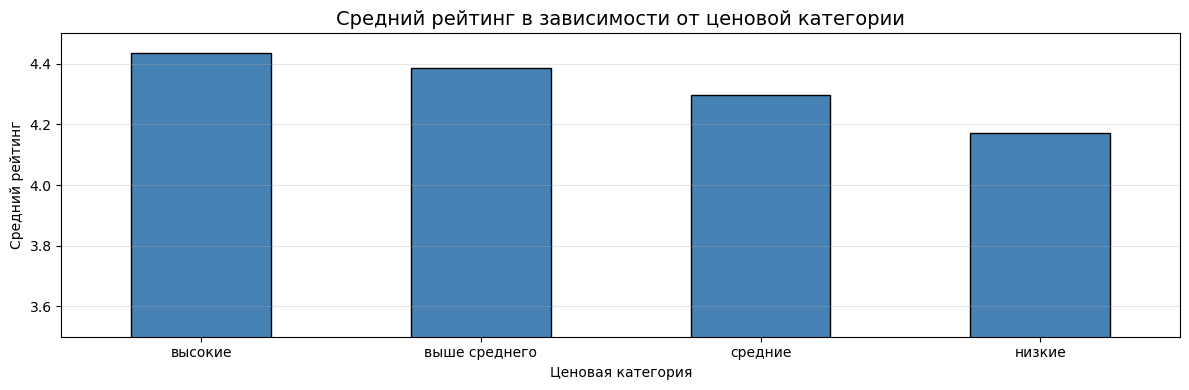

In [47]:
plt.figure(figsize=(12, 4))

price_rating = df.groupby('price')['rating'].mean().sort_values(ascending=False)

price_rating.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Средний рейтинг в зависимости от ценовой категории', fontsize=14)
plt.xlabel('Ценовая категория')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=0)
plt.ylim(3.5, 4.5)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Ожидаемо, чем выше ценовая категория, тем больше средний рейтинг заведения, что указывает на зависимость качества и доверия покупателей от цены ассортимента заведения. Но значения отличаются не слишком сильно, что показывает примерную равномерность рейтинга заведений в зависимости от ценовой категории. 

Для анализа важно знать самые распространенные сетевые заведения в Москве. Это фавориты по количеству заведений. Далее выделим 15 самых популярных и посчитаем для них средний рейтинг. Обе составляющие визуализируем с помощью линейчатых диаграмм.

In [48]:
chain_inf = df[df['chain'] == 1].groupby('name')['rating'].agg(['mean', 'count']).sort_values('count', ascending=False).head(15)
print(chain_inf)

                                         mean  count
name                                                
шоколадница                          4.177500    120
домино'с пицца                       4.169737     76
додо пицца                           4.286486     74
one price coffee                     4.064789     71
яндекс лавка                         3.872464     69
cofix                                4.075385     65
prime                                4.116000     50
хинкальная                           4.322727     44
кофепорт                             4.147619     42
кулинарная лавка братьев караваевых  4.394872     39
теремок                              4.123684     38
чайхана                              3.924324     37
cofefest                             3.984375     32
буханка                              4.396875     32
му-му                                4.229630     27


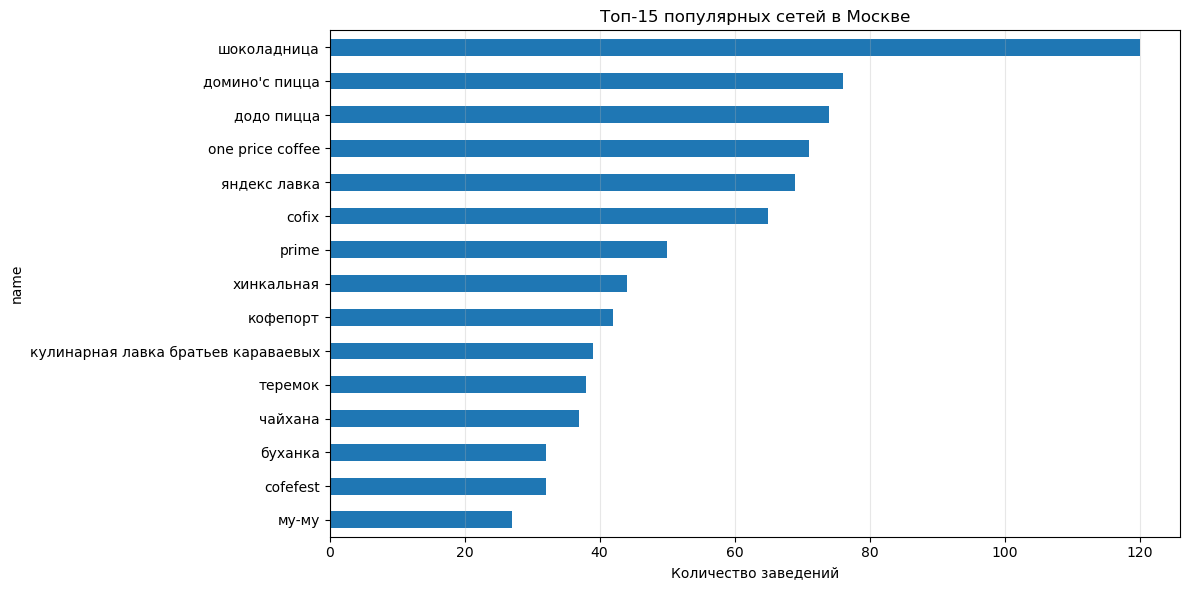

In [49]:
plt.figure(figsize=(12, 6))
chain_inf['count'].sort_values().plot(kind='barh')
plt.title('Топ-15 популярных сетей в Москве')
plt.xlabel('Количество заведений')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Самой популярной сетью в Москве является Шоколадница со 120 заведениями. Значения в топ-15 имеют большой разброс – от 27 до 120 заведений, что говорит о том, что в Москве не так много заведений с большим количеством сетевых точек. Если принимать за большое количество сетевых точек значения >50, то таких заведений окажется только 7. 

<Figure size 1200x600 with 0 Axes>

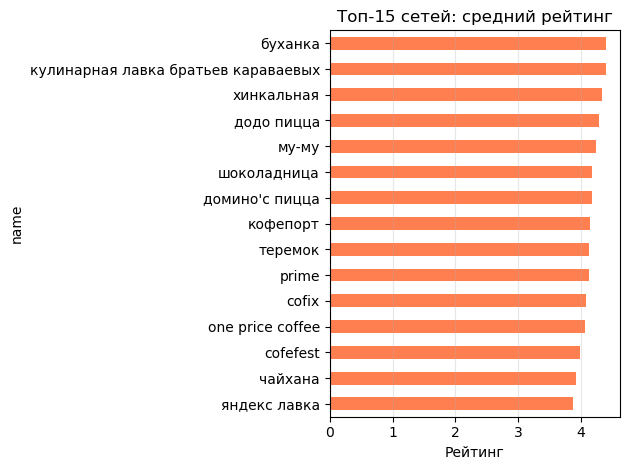

<Figure size 1200x600 with 0 Axes>

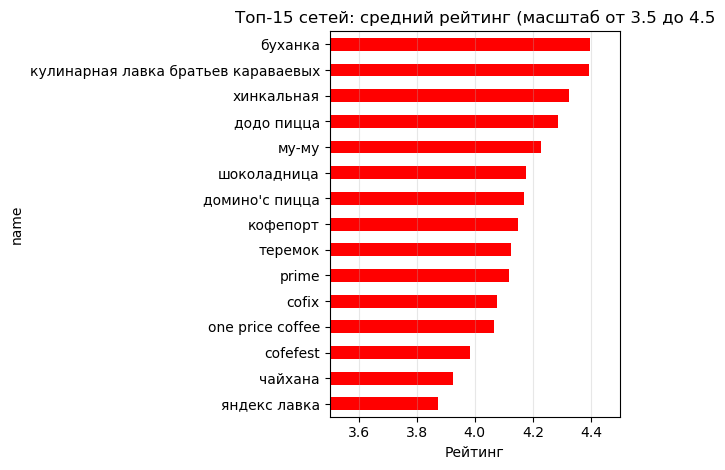

In [50]:
plt.figure(figsize=(12, 6))
chain_inf.sort_values('mean').plot(kind='barh', y='mean', color='coral', legend=False)
plt.title('Топ-15 сетей: средний рейтинг')
plt.xlabel('Рейтинг')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 6))
chain_inf.sort_values('mean').plot(kind='barh', y='mean', color='red', legend=False)
plt.title('Топ-15 сетей: средний рейтинг (масштаб от 3.5 до 4.5')
plt.xlabel('Рейтинг')
plt.xlim(3.5, 4.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Средний рейтинг вышепредставленных топ-15 заведений по количеству сетевых точек представлен на графиках в стопроцентном масштабе и в масштабе от 3.5 до 4.5. Самыми высокорейтинговыми из популярных заведений являются Буханка и Кулинарная лавка братьев Караваевых со значениями около 4.4. Остальные значения находятся в диапазоне от примерно 3.9 до 4.4. Это говорит о том, что популярность не всегда гарантирует высокий рейтинг.

Проанализируем также категории топ-15 популярных заведений Москвы. 

In [51]:
chain_inf = df[df['chain'] == 1]['name'].value_counts().head(15).index

for name in chain_inf:
    category = df[df['name'] == name]['category'].values[0]
    print(f"{name} - {category}")


шоколадница - кофейня
домино'с пицца - пиццерия
додо пицца - пиццерия
one price coffee - кофейня
яндекс лавка - ресторан
cofix - кофейня
prime - ресторан
хинкальная - быстрое питание
кофепорт - кофейня
кулинарная лавка братьев караваевых - кафе
теремок - ресторан
чайхана - кафе
буханка - булочная
cofefest - кофейня
му-му - кафе


In [52]:
category_points = df[(df['chain'] == 1) & (df['name'].isin(chain_inf))].groupby('category')['name'].count()

category_share = (category_points / category_points.sum()) * 100

print("Распределение топ-15 сетей по категориям (по количеству заведений):")
print(category_points.sort_values)
print(category_share)

Распределение топ-15 сетей по категориям (по количеству заведений):
<bound method Series.sort_values of category
бар,паб              4
булочная            25
быстрое питание     12
кафе               100
кофейня            336
пиццерия           151
ресторан           186
столовая             2
Name: name, dtype: int64>
category
бар,паб             0.490196
булочная            3.063725
быстрое питание     1.470588
кафе               12.254902
кофейня            41.176471
пиццерия           18.504902
ресторан           22.794118
столовая            0.245098
Name: name, dtype: float64


Среди топ-15 сетей Москвы доминируют кофейни (41.2% или 336 заведений), рестораны (22.8% или 186 заведений) и пиццерии (18.5% или 151 заведение). В сумме эти три категории занимают более 82% всех заведений, входящих в крупнейшие сети. Кафе составляют лишь 12.3% (100 заведений), а булочные (3.1% или 25 заведений), бары/пабы (0.5% или 4 заведения) и столовые (0.2% или 2 заведения) представлены незначительно.

Необходимо исследовать районы Москвы по значению среднего чека, чтобы выявить их средние значения по району, медиану, минимальное и максимальное значения.

In [53]:
district_avg = (df.groupby('district_short')['middle_avg_bill']
                .agg(['mean', 'median', 'min', 'max']).sort_values('mean', ascending=False))
print(district_avg)

                       mean  median    min      max
district_short                                     
ЦАО             1191.057547  1000.0    0.0   7250.0
ЗАО             1053.225490  1000.0   50.0   5250.0
САО              927.959627   650.0  130.0  11000.0
ЮАО              834.398089   500.0  100.0  35000.0
СЗАО             822.222930   700.0  120.0   2900.0
ВАО              820.626923   575.0   50.0  10000.0
ЮЗАО             792.561702   600.0  100.0   2750.0
СВАО             716.611296   500.0   50.0   4500.0
ЮВАО             654.097938   450.0   30.0   3750.0


In [54]:
#Подробнее изучим отдельно ЦАО и другие районы в общем
cao = df[df['district'] == 'центральный административный округ']['middle_avg_bill'].describe()
print("ЦАО:")
print(cao)

others = df[df['district'] != 'центральный административный округ']['middle_avg_bill'].describe()
print("\nДругие районы:")
print(others)

ЦАО:
count    1060.000000
mean     1191.057547
std       920.014707
min         0.000000
25%       500.000000
50%      1000.000000
75%      1500.000000
max      7250.000000
Name: middle_avg_bill, dtype: float64

Другие районы:
count     2089.000000
mean       839.822882
std       1032.624097
min         30.000000
25%        350.000000
50%        600.000000
75%       1150.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64


ЦАО ожидаемо имеет самое высокое среднее значение, так как там находится больше всего заведений и большинство из них – рестораны. Однако медиана совпадает с ЗАО, их средние значения тоже близки, что говорит о том, что несмотря на сильно меньшее количество заведений, ЗАО наравне по среднему чеку с ЦАО. Из данных выбивается минимальный чек в ЦАО, равный 0, что может быть ошибкой в данных. Также максимальное значение в ЮАО размером 35000 явно ошибочно, что сильно искажает данные этого района и всех районов, кроме ЦАО в общем.
ЦАО и другие районы имеют достаточно высокое страндартное отклонение (примерно 920 и 1033), что говорит о большом разбросе среднего чека в заведениях. Среднее значение по другим районам (около 840) достаточно сильно отличается от среднего значения ЦАО (1191), как и если смотреть медиану по каждому району, никто кроме ЗАО не близок к ЦАО (значения от 450 до 650). 

<Figure size 1200x1000 with 0 Axes>

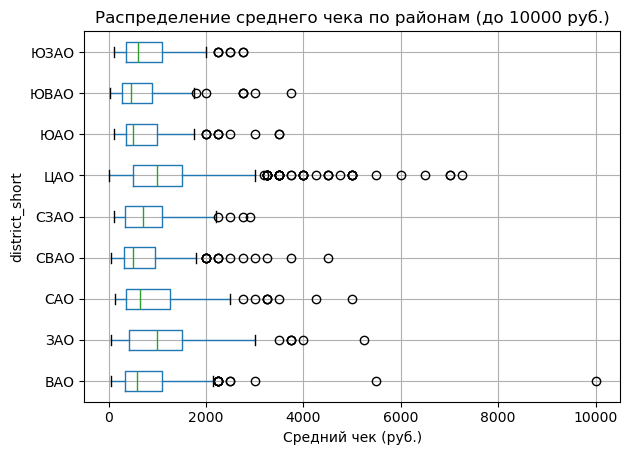

In [55]:
plot_data = df[df['middle_avg_bill'] <= 10000]

plt.figure(figsize=(12, 10))
plot_data.boxplot(column='middle_avg_bill', by='district_short', vert=False)
plt.title('Распределение среднего чека по районам (до 10000 руб.)')
plt.suptitle('')
plt.xlabel('Средний чек (руб.)')
plt.tight_layout()
plt.show()

Чтобы избежать аномальных значений ограничим данные до 10000 руб. На "ящике с усами" хорошо видно выбросы по районам, особенно выделяется значение в ВАО. Больше всего выбросов в ЦАО, что подтверждается самым высоким средним чеком и самым большим количеством заведений, поэтому эти значения не искажают данные. В других районах есть высокие значения, которые могут быть ошибками или заведениями с очень высоким чеком, так как их немного, это не сильно повлияет на данные. 

---

#### Промежуточные выводы

Исследовательский анализ данных показал, что:

- Самой популярной категорией заведений в городе является кафе (28%), однако в ЦАО преобладают рестораны (около 30%).
- В ЦАО находится больше всего заведений (более 2000), в то время как в других районах значения не доходят и до 1000 заведений
- Большинство заведений (около 62%) несетевые. Только категория кофеен содержит в себе больше сетевых заведений. 
- Больше всего посадочных мест в ресторанах (по медиане 86), а самый высокий рейтинг в среднем у баров, пабов (около 4,39).
- Корреляция между рейтингом и другими показателями низкая. Самое высокое значение у категории цен (0,22).
- В топ-15 заведений Москвы первое место занимает Шоколадница (120 заведений). Среди этих заведений самый высокий рейтинг у Буханки. А самая популярная категория среди них – кофейня (5).
- В ЦАО самый высокий средний чек (1191), но его медиана такая же как у ЗАО (1000). Остальные районы имеют медиану в пределах 450-650 руб.

---

### 4. Итоговый вывод и рекомендации

В ходе исследования были проанализированы данные 8406 заведений общественного питания Москвы. Данные включали информацию о заведениях и о ценах внутри них. Акцент был сделан на достижении понимания ситуации на рынке и его основных тенденций. Среди главных аспектов: изучение категорий заведений, районов их размещения, посадочных мест, среднего рейтинга и топ-15 популярных сетевых заведений столицы.  

### Главные выводы

Исследование рынка заведений общественного питания позволяет сделать следующие выводы:

- Большинство заведений находятся в Центральном административном округе (около 26,7%). Там преобладают рестораны и самый высокий средний чек в городе (1191). Это самое востребованное место для размещения заведения общественного питания.
- Другие районы слабо конкурируют с ЦАО. Только ЗАО имеет одинаковую медиану среднего чека (1000). Другие районы представляют медиану от 450 до 650 руб., что значительно ниже, чем в ЦАО. Они представляют собой 73,3% заведений города. 
- Несетевые заведения преобладают в Москве (около 62%), большинство из них – это кафе и рестораны. Кафе, в том числе, является и самой популярной категорией заведений в городе (28%).
- В заведениях обычно не более 86 посадочных мест (самое высокое значение – рестораны), однако встречаются заведения с очень высоким количеством посадочных мест (больше 1000).
- После анализа корреляции рейтинга заведений с другими показателями, сильной связи не было выявлено. 
- Из топ-15 популярных сетевых заведений общественного питания Москвы выделяется Шоколадница со 120 заведниями. Разброс популярных заведений проходит от 27 до 120 заведений, что свидетельствует о небольшом количестве "сетевых гигантов", таких как Шоколадница.

### Рекомендации

После анализа рынка заведений общественного питания Москвы, я бы порекомендовала подробнее изучить размещение заведений в ЦАО, потому что он является самым востребованным и популярным в городе. 

Особенное внимание надо уделить рейтингу, так как сильной корреляции с изучаемыми категориями не было, важно предусмотреть другие обстоятельства, например качество еды или обслуживания, близость к метро и т.д., которые могут влиять на рейтинг заведения, что является важным показателем. 

В качестве категории стоит рассмотреть кофейни, если планируется сетевое размещение. В другом случае, хорошим вариантом будут ресторан, кафе и бар, паб, которые показывают хорошие несетевые показатели.